In [3]:
import sys

print(sys.executable)

c:\Users\Jai Shree Shyam\Hotel-Demand-Analytics-and-Cancellation-Prediction-Project\venv\Scripts\python.exe


In [4]:
## LOAD THE DATASET 

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

sns.set_style("whitegrid")

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [5]:
## READ THE DATASET

df = pd.read_csv("../data/raw/hotel_bookings.csv")

print(df.shape)

df.head()

(119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


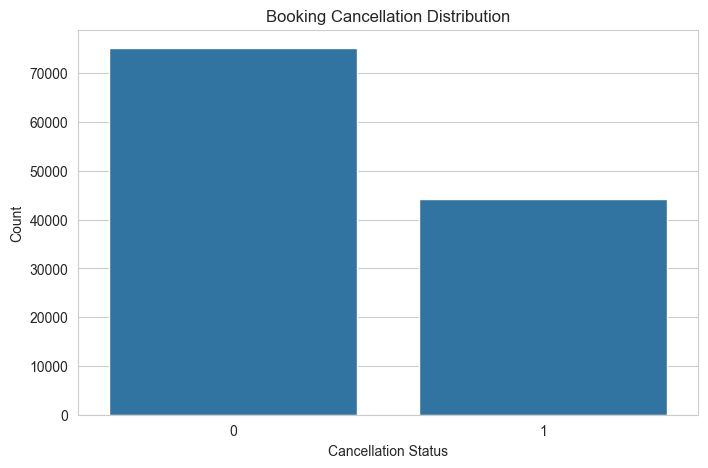

In [6]:
## CREATE CANCELLATION COUNT PLOT

plt.figure(figsize=(8,5))

sns.countplot(
    x = 'is_canceled', 
    data = df
)

plt.title("Booking Cancellation Distribution")
plt.xlabel("Cancellation Status")
plt.ylabel("Count")

plt.show()

In [7]:
## ANALYZE HOTEL TYPE vs CANCELLATION RATE

hotel_cancel = pd.crosstab(
    df["hotel"],
    df["is_canceled"],
    normalize="index"
) * 100

hotel_cancel

is_canceled,0,1
hotel,,
City Hotel,58.273037,41.726963
Resort Hotel,72.236645,27.763355


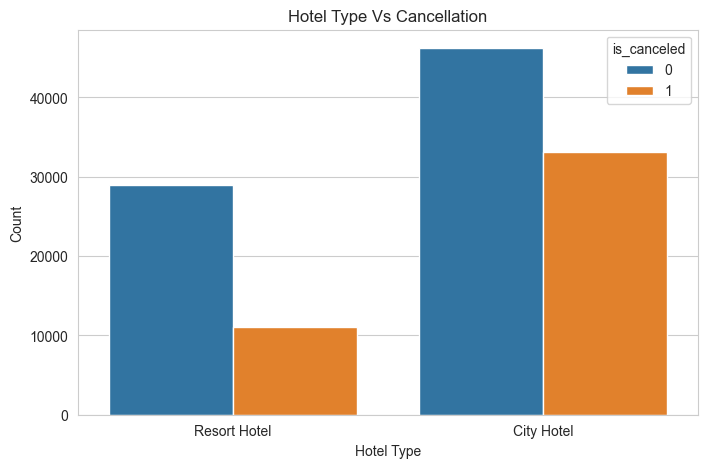

In [8]:
## VISULAIZATION OF THE DATA

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="hotel",
    hue="is_canceled"
)

plt.title("Hotel Type Vs Cancellation")
plt.xlabel("Hotel Type")
plt.ylabel("Count")

plt.show()

### Observation

- City Hotels have a significantly higher cancellation rate (41.73%) than Resort Hotels (27.76%).
- Resort Hotels show better booking retention.
- Hotel type appears to be a strong predictor of cancellation behavior.
- This variable should be retained for machine learning models.

In [9]:
# LEAD TIME vs CANCELLATION
## COMPARE AVERAGE LEAD TIME

df.groupby("is_canceled")["lead_time"].mean()


is_canceled
0     79.984687
1    144.848815
Name: lead_time, dtype: float64

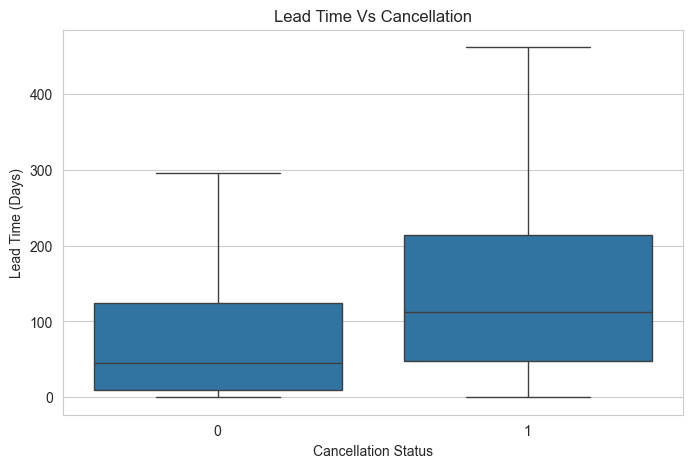

In [10]:
## VISULAIZATION OF THE DATA

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df, 
    x="is_canceled",
    y="lead_time",
    showfliers=False
)

plt.title("Lead Time Vs Cancellation")
plt.xlabel("Cancellation Status")
plt.ylabel("Lead Time (Days)")

plt.show()

### Observation

- Cancelled bookings generally have much higher lead times.
- Customers booking far in advance are more likely to cancel.
- Lead Time appears to be one of the strongest predictors of cancellation.
- This feature should definitely be retained during model building.

In [11]:
# MARKET SEGMENT vs CANCELLATION RATE
## VIEW MARKET SEGMENTS

df["market_segment"].value_counts()

market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: count, dtype: int64

In [12]:
## CALCULATE CANCELLATION RATE BY SEGMENT

segment_cancel = pd.crosstab(
    df["market_segment"],
    df["is_canceled"],
    normalize="index"
) * 100

segment_cancel

is_canceled,0,1
market_segment,,
Aviation,78.059072,21.940928
Complementary,86.944818,13.055182
Corporate,81.265345,18.734655
Direct,84.658099,15.341901
Groups,38.937964,61.062036
Offline TA/TO,65.683967,34.316033
Online TA,63.278857,36.721143
Undefined,0.000000,100.000000


In [13]:
## SORT BY CANCELLATION PERCENTAGE

segment_cancel.sort_values(
    by=1,
    ascending=False
)

is_canceled,0,1
market_segment,,
Undefined,0.000000,100.000000
Groups,38.937964,61.062036
Online TA,63.278857,36.721143
Offline TA/TO,65.683967,34.316033
Aviation,78.059072,21.940928
Corporate,81.265345,18.734655
Direct,84.658099,15.341901
Complementary,86.944818,13.055182


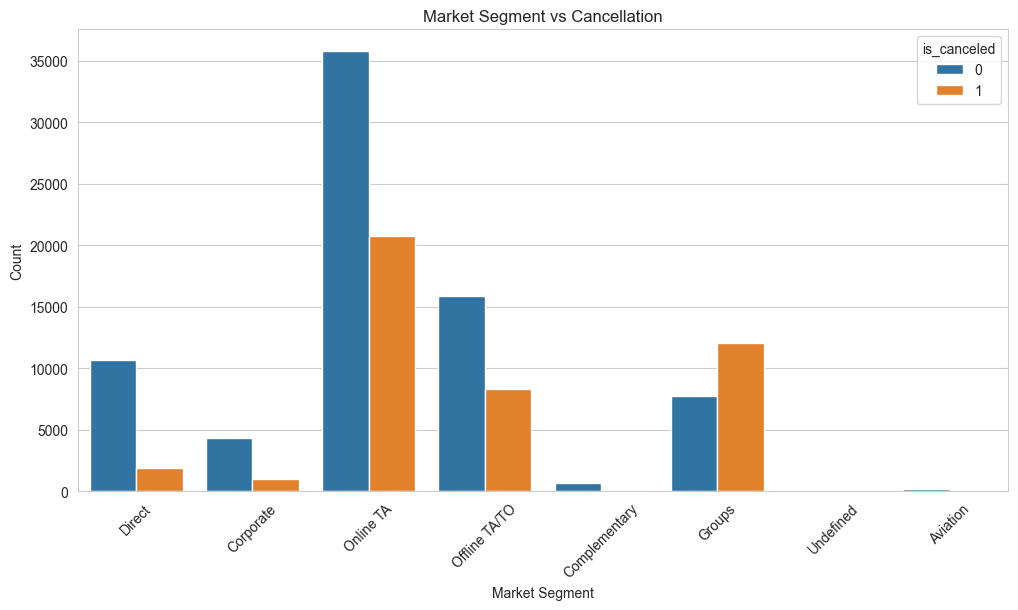

In [14]:
## VISUALIZATION OF THE DATA

plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x="market_segment",
    hue="is_canceled"
)

plt.title("Market Segment vs Cancellation")
plt.xlabel("Market Segment")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

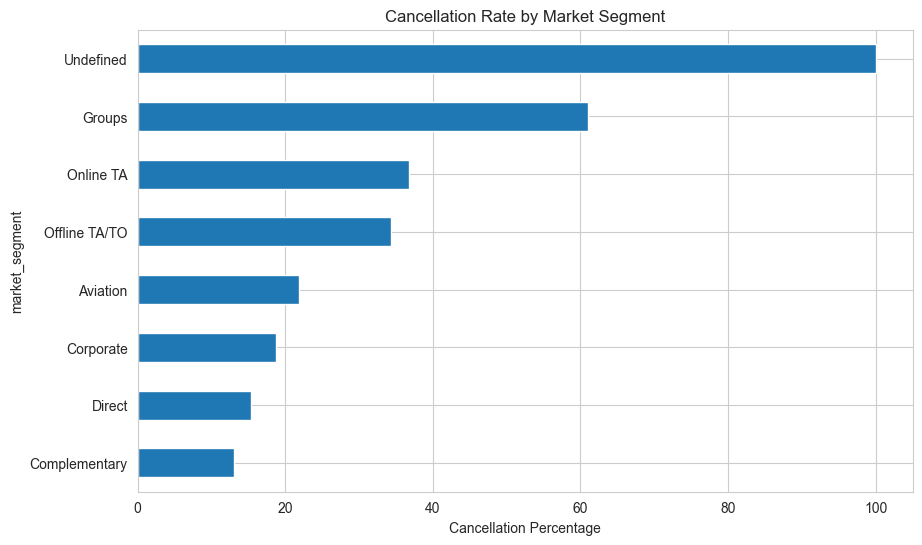

In [15]:
segment_cancel[1].sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Cancellation Rate by Market Segment")
plt.xlabel("Cancellation Percentage")

plt.show()

### Observation

- Group bookings show the highest cancellation rate (61.06%).
- Online Travel Agencies have significantly higher cancellation rates than direct bookings.
- Direct and Corporate customers are relatively reliable.
- Market Segment is a strong predictor of cancellation behavior.
- Booking source should be retained for machine learning modeling.

In [16]:
# DEPOSIT TYPE vs CANCELLATION
## CHECK SAMPLE SIZE

df["deposit_type"].value_counts()

deposit_type
No Deposit    104641
Non Refund     14587
Refundable       162
Name: count, dtype: int64

In [17]:
## CALCULATE CANCELLATION RATE BY DEPOSIT TYPE

deposit_cancel = pd.crosstab(
    df["deposit_type"],
    df["is_canceled"],
    normalize="index"
) * 100

deposit_cancel.sort_values(
    by=1,
    ascending=False
)

is_canceled,0,1
deposit_type,,
Non Refund,0.637554,99.362446
No Deposit,71.622978,28.377022
Refundable,77.777778,22.222222


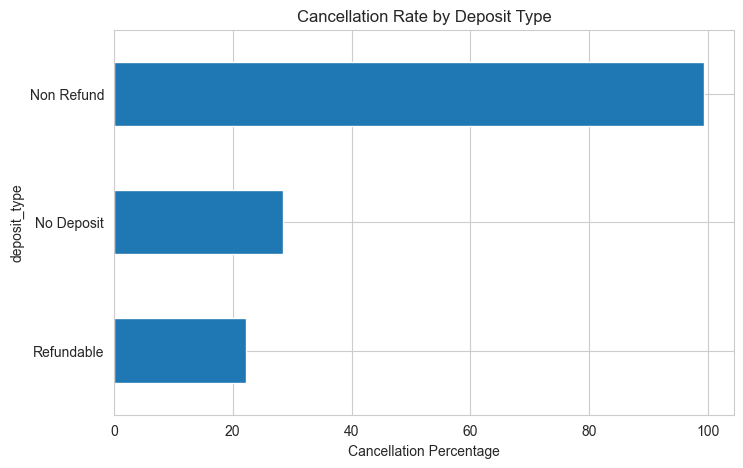

In [18]:
## VISUALIZATION OF THE DATA

deposit_cancel[1].sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Cancellation Rate by Deposit Type")
plt.xlabel("Cancellation Percentage")

plt.show()

### Observation

- Deposit Type has a strong relationship with cancellation behavior.
- Non Refund bookings show an extremely high cancellation rate (99.36%).
- No Deposit bookings have a cancellation rate of 28.38%.
- Refundable bookings have the lowest cancellation rate (22.22%).
- Deposit Type appears to be a highly predictive feature.

In [19]:
# CUSTOMER TYPE vs CANCELLATION
## VIEW CUSTOMER TYPE DISTRIBUTION

df["customer_type"].value_counts()

customer_type
Transient          89613
Transient-Party    25124
Contract            4076
Group                577
Name: count, dtype: int64

In [20]:
## CALCULATE CANCELLATION RATE BY CUSTOMER TYPE

customer_cancel = pd.crosstab(
    df["customer_type"],
    df["is_canceled"],
    normalize="index"
) * 100

customer_cancel.sort_values(
    by=1,
    ascending=False
)

is_canceled,0,1
customer_type,,
Transient,59.253680,40.746320
Contract,69.038273,30.961727
Transient-Party,74.570132,25.429868
Group,89.774697,10.225303


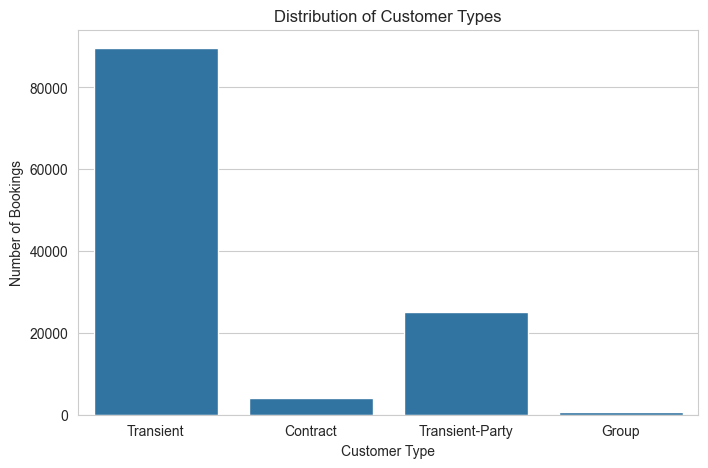

In [21]:
## VISUALIZATION CUSTOMER DISTRIBUTION

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="customer_type"
)

plt.title("Distribution of Customer Types")
plt.xlabel("Customer Type")
plt.ylabel("Number of Bookings")

plt.show()

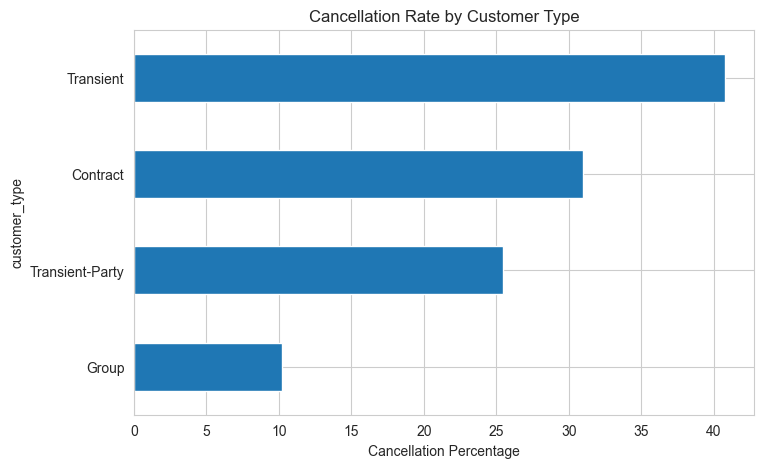

In [22]:
## VISUALIZATION CANCELLATION RATE

customer_cancel[1].sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Cancellation Rate by Customer Type")
plt.xlabel("Cancellation Percentage")

plt.show()

### Final Observation

Customer Type has a noticeable impact on cancellation behavior.

- Transient customers exhibit the highest cancellation rate (40.75%).
- Contract customers show moderate cancellation behavior (30.96%).
- Transient-Party customers are comparatively more reliable (25.43%).
- Group customers have the lowest cancellation rate (10.23%).

These findings suggest that Customer Type contains valuable predictive information and should be retained during machine learning model development.

## DATA CLEANING AND FEATURE ENGINEERING

In [23]:
## CHECK THE MISSING VALUES

df.isnull().sum()


hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [24]:
## HANDLE MISSING VALUES

df["children"] = df["children"].fillna(0)
df["agent"] = df["agent"].fillna(0)
df["country"] = df["country"].fillna("Unkown")
df["company"] = df["company"].fillna(0)

df.isnull().sum()


hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

### Missing Value Handling

- children had only 4 missing values and was replaced with 0.
- country missing values were replaced with "Unknown".
- agent and company contained large numbers of missing values and were replaced with 0.
- Dataset is now ready for feature engineering.

In [25]:
## CONVERT DATE COLUMN

df["reservation_status_date"] = pd.to_datetime(df["reservation_status_date"])
df["reservation_status_date"].dtype

dtype('<M8[us]')

In [26]:
## CREATE TOTAL NIGHTS COLUMN

df["total_nights"] = df["stays_in_weekend_nights"] +  df["stays_in_week_nights"]
df[["stays_in_weekend_nights", "stays_in_week_nights", "total_nights"]].head()

,stays_in_weekend_nights,stays_in_week_nights,total_nights
0,0,0,0
1,0,0,0
2,0,1,1
3,0,1,1
4,0,2,2


In [27]:
## CREATE TOTAL GUESTS COLUMN

df["total_guests"] = df["adults"] + df["children"] + df["babies"]
df[["adults", "children", "babies","total_guests"]].head()

,adults,children,babies,total_guests
0,2,0.0,0,2.0
1,2,0.0,0,2.0
2,1,0.0,0,1.0
3,1,0.0,0,1.0
4,2,0.0,0,2.0


In [28]:
## CREATE ARRIVAL MONTH(NUM) COLUMN

df["arrival_date_num"] = pd.to_datetime(
    df["arrival_date_month"],
    format="%B"
).dt.month

df[["arrival_date_month", "arrival_date_num"]].head()

,arrival_date_month,arrival_date_num
0,July,7
1,July,7
2,July,7
3,July,7
4,July,7


In [29]:
## CREATE STAY TYPE COLUMN

df["stay_type"] = np.where(
    df["total_nights"] <=3,
    "Short Stay",
    np.where(df["total_nights"] <=7, "Medium Stay", "Long Stay")
)

df["stay_type"].value_counts()

stay_type
Short Stay     76454
Medium Stay    37679
Long Stay       5257
Name: count, dtype: int64

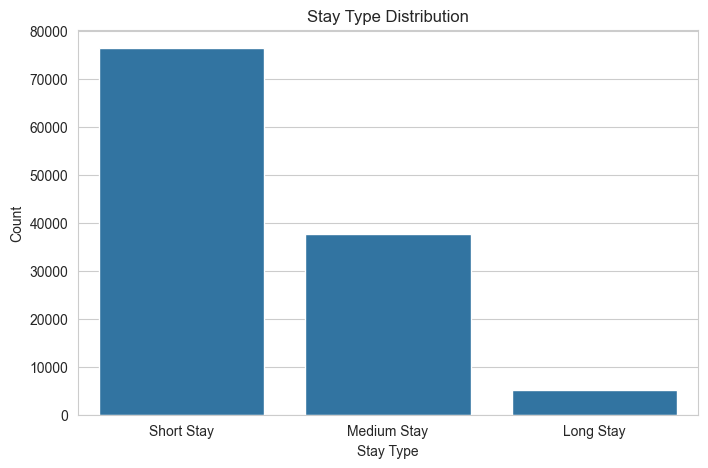

In [30]:
## VISUALIZE STAY TYPE

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="stay_type",
    order=df["stay_type"].value_counts().index
)

plt.title("Stay Type Distribution")
plt.xlabel("Stay Type")
plt.ylabel("Count")

plt.show()

In [31]:
## SAVE CLEANED DATASET

df.to_csv("../data/processed/hotel_bookings_cleaned.csv", index=False)

print("Cleaned Dataset Saved Successfully")

Cleaned Dataset Saved Successfully


In [32]:
## VERIFY SAVED FILE

import os

os.path.exists("../data/processed/hotel_bookings_cleaned.csv")

True

# Day 3 Summary

Completed Tasks:

- Missing value handling
- Date parsing
- Feature engineering
- Created total_nights
- Created total_guests
- Created arrival_month_num
- Created stay_type
- Saved cleaned dataset

Key Findings:

- City Hotels have higher cancellation rates.
- Long lead times increase cancellation probability.
- Online Travel Agencies contribute significantly to cancellations.
- Deposit type strongly influences cancellation behaviour.
- Customer type impacts booking reliability.

The dataset is now cleaned and prepared for SQL analytics and dashboard development.

In [39]:
import pandas as pd
import plotly.express as px

df = pd.read_csv("../data/processed/hotel_bookings_cleaned.csv")

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_nights,total_guests,arrival_date_num,stay_type
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,0.0,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01,0,2.0,7,Short Stay
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,0.0,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01,0,2.0,7,Short Stay
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,0.0,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02,1,1.0,7,Short Stay
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02,1,1.0,7,Short Stay
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,0.0,0,Transient,98.0,0,1,Check-Out,2015-07-03,2,2.0,7,Short Stay


In [ ]:
## MONTHLY BOOKING TREND

month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

monthly_bookings = (
    df.groupby(["arrival_date_month", "hotel"])
    .size()
    .reset_index(name="bookings")
)

monthly_bookings["arrival_date_month"] = pd.Categorical(
    monthly_bookings["arrival_date_month"],
    categories=month_order,
    ordered=True
)

monthly_bookings = monthly_bookings.sort_values("arrival_date_month")

fig = px.line(
    monthly_bookings,
    x="arrival_date_month",
    y="bookings",
    color="hotel",
    markers=True,
    title="Monthly Booking Trend by Hotel Type",
)

fig.update_layout(
    xaxis_title="Arrival Month",
    yaxis_title="Number of Bookings"
)

fig.show()

### Business Insight

- Booking demand shows strong seasonality throughout the year.
- August recorded the highest number of bookings.
- July was the second busiest month.
- Demand generally increases from January to August before declining toward the end of the year.
- City Hotel consistently receives more bookings than Resort Hotel across all months.
- Seasonal demand patterns can help hotels optimize pricing and staffing decisions.

In [48]:
## HOTEL TYPE COMPARISON

hotel_comparison = (
    df.groupby("hotel")
    .agg(
        total_bookings=("hotel", "count"),
        avg_adr=("adr", "mean"),
        avg_nights=("total_nights", "mean"),
        cancellation_rate=("is_canceled", "mean")
    )
    .reset_index()
)

hotel_comparison["cancellation_rate"] = hotel_comparison["cancellation_rate"] * 100

hotel_comparison


,hotel,total_bookings,avg_adr,avg_nights,cancellation_rate
0,City Hotel,79330,105.304465,2.978142,41.726963
1,Resort Hotel,40060,94.952930,4.318547,27.763355


In [ ]:
## VISUALIZATION

fig = px.bar(
    hotel_comparison,
    x="hotel",
    y="total_bookings",
    title="Total Bookings by Hotel Type",
    text="total_bookings"
)

fig.update_layout(
    xaxis_title="Hotel Type",
    yaxis_title="Total Bookings"
)

fig.show()

### Business Insight

- City Hotel generates nearly twice as many bookings as Resort Hotel.
- City Hotel has a higher average ADR.
- Resort Hotel guests stay longer on average.
- City Hotel experiences substantially higher cancellation rates.

In [49]:
## CANCELLATION RATE BY CUSTOMER TYPE

cancel_customer = (
    df.groupby("customer_type")
    .agg(
        total_bookings=("is_canceled", "count"),
        cancelled_bookings=("is_canceled", "sum"),
        cancellation_rate=("is_canceled", "mean")
    )
    .reset_index()
)

cancel_customer["cancellation_rate"] = cancel_customer["cancellation_rate"] * 100
cancel_customer = cancel_customer.sort_values("cancellation_rate", ascending=False)

fig = px.bar(
    cancel_customer,
    x="customer_type",
    y="cancellation_rate",
    title="Cancellation Rate by Customer Type",
    text=cancel_customer["cancellation_rate"].round(2)
)

fig.update_layout(
    xaxis_title="Customer Type",
    yaxis_title="Cancellation Rate (%)"
)

fig.show()

### Business Insight

Transient customers exhibit the highest cancellation rate, making them the highest-risk segment. Group bookings demonstrate the lowest cancellation rate and are more predictable.

In [72]:
## ADR DISTRIBUTION
df["adr"].describe()

count    119390.000000
mean        101.831122
std          50.535790
min          -6.380000
25%          69.290000
50%          94.575000
75%         126.000000
max        5400.000000
Name: adr, dtype: float64

In [73]:
df[df["adr"] > 1000][["hotel","adr"]].head()

,hotel,adr
48515,City Hotel,5400.0


In [74]:
df[df["adr"] > 1000]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_nights,total_guests,arrival_date_num,stay_type
48515,City Hotel,1,35,2016,March,13,25,0,1,2,0.0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,A,A,1,Non Refund,12.0,0.0,0,Transient,5400.0,0,0,Canceled,2016-02-19,1,2.0,3,Short Stay


In [75]:
## ADR VISUALIZATION

adr_filtered = df[df["adr"] <= 300]

fig = px.histogram(
    adr_filtered,
    x="adr",
    nbins=50,
    title="ADR Distribution (Without Extreme Outliers)"
)

fig.update_layout(
    xaxis_title="Average Daily Rate",
    yaxis_title="Number of Bookings"
)

fig.show()

### Business Insight

- Most bookings have ADR values between 50 and 150.
- The distribution is positively skewed, with a small number of premium-priced bookings.
- ADR values above 250 are rare.
- The dataset contains a small number of anomalous ADR values, including negative and extremely high values.
- Outlier treatment will be performed before model development.

In [54]:
## CUSTOMER SEGMENT BREAKDOWN

segment_bookings = (
    df["market_segment"]
    .value_counts()
    .reset_index()
)

segment_bookings.columns = ["market_segment", "bookings"]

fig = px.bar(
    segment_bookings,
    x="market_segment",
    y="bookings",
    title="Bookings by Market Segment",
    text="bookings"
)

fig.update_layout(
    xaxis_title="Market Segment",
    yaxis_title="Number of Bookings"
)

fig.show()

### Business Insight

Online Travel Agencies are the dominant booking channel. This highlights the importance of OTA partnerships and digital distribution strategies.

In [61]:
## CANCELLATION HEATMAP

heatmap_data = pd.pivot_table(
    df,
    values="is_canceled",
    index="arrival_date_month",
    columns="hotel",
    aggfunc="mean"
) * 100

heatmap_data = heatmap_data.reindex(month_order)

heatmap_data

hotel,City Hotel,Resort Hotel
arrival_date_month,,
January,39.668094,14.819881
February,38.288016,25.620367
March,36.946423,22.871703
April,46.323529,29.343308
May,44.375607,28.772127
June,44.692171,33.070608
July,40.875371,31.401706
August,40.097963,33.449121
September,42.027027,32.368082


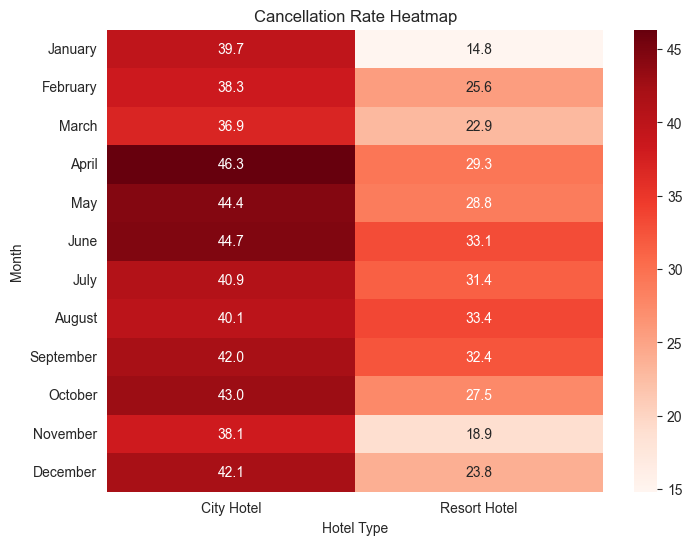

In [ ]:
## VISUALIZATION

plt.figure(figsize=(8,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="Reds"
)

plt.title("Cancellation Rate Heatmap")
plt.xlabel("Hotel Type")
plt.ylabel("Month")

plt.show()

### Business Insight

- City Hotel experiences significantly higher cancellation rates than Resort Hotel throughout the year.
- Cancellation rates exceed 40% for City Hotel during several months.
- April and June show the highest cancellation risk.
- Seasonal cancellation patterns suggest targeted retention strategies may be required during peak-risk periods.

In [63]:
## ADR BY CUSTOMER TYPE

adr_customer = (
    df.groupby("customer_type")
    .agg(
        avg_adr=("adr","mean")
    )
    .reset_index()
)

adr_customer

,customer_type,avg_adr
0,Contract,87.549637
1,Group,83.488579
2,Transient,107.013621
3,Transient-Party,86.084253


In [67]:
## VISUALIZATION

fig = px.bar(
    adr_customer,
    x="customer_type",
    y="avg_adr",
    text=adr_customer["avg_adr"].round(2),
    title="Average ADR by Customer Type"
)

fig.update_layout(
    xaxis_title="Customer Type",
    yaxis_title="Average ADR"
)

fig.show()

### Business Insight

- Transient customers generate the highest average ADR.
- Group bookings have the lowest ADR.
- Contract and Transient-Party customers fall within a similar pricing range.
- Since Transient customers also exhibit the highest cancellation rates, they represent both a revenue opportunity & a business risk.

# Day 7 Summary

## Visualizations Created

1. Monthly Booking Trend
2. Hotel Type Comparison
3. Cancellation Rate by Customer Type
4. ADR Distribution
5. Market Segment Analysis
6. Cancellation Heatmap
7. ADR by Customer Type

## Key Findings

- August recorded the highest booking volume.
- City Hotel generated the majority of bookings.
- City Hotel experienced significantly higher cancellation rates.
- Transient customers showed the highest ADR and cancellation risk.
- Online TA was the dominant booking channel.
- ADR contains a small number of extreme outliers that will be addressed during model preparation.